In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [9]:
from google.colab import files

uploaded = files.upload()

Saving seasonal_agriculture_performance_dataset .csv to seasonal_agriculture_performance_dataset  (2).csv


In [12]:
df = pd.read_csv("seasonal_agriculture_performance_dataset .csv")

In [14]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [16]:
df.columns

Index(['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares',
       'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
       'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
       'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method',
       'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
       'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne',
       'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3',
       'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct'],
      dtype='object')

In [17]:
df.isnull().sum()

,0
Farm_ID,0
State,0
District,0
Crop,0
Season,0
Farm_Area_Hectares,0
Rainfall_mm,48
Avg_Temperature_C,0
Humidity_pct,0
Sunlight_Hours_Day,0


In [18]:
df["Season"].value_counts()

,count
Season,
Kharif,1779
Rabi,1627
Zaid,594


In [20]:
season_yield = df.groupby("Season")["Yield_Tonnes_Ha"].mean()

season_yield

,Yield_Tonnes_Ha
Season,
Kharif,5.643973
Rabi,5.080498
Zaid,4.665942


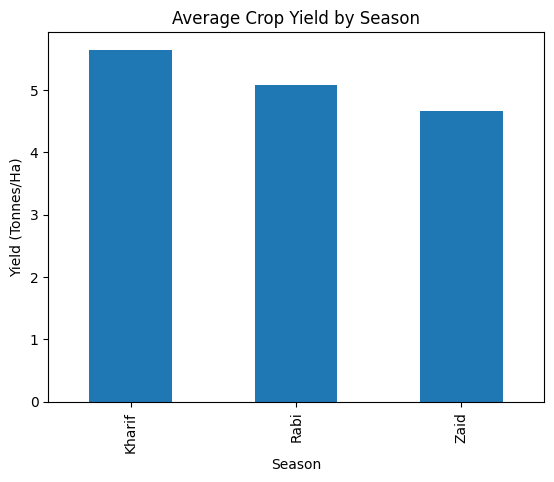

In [21]:
import matplotlib.pyplot as plt

season_yield.plot(kind="bar")

plt.title("Average Crop Yield by Season")
plt.xlabel("Season")
plt.ylabel("Yield (Tonnes/Ha)")
plt.show()

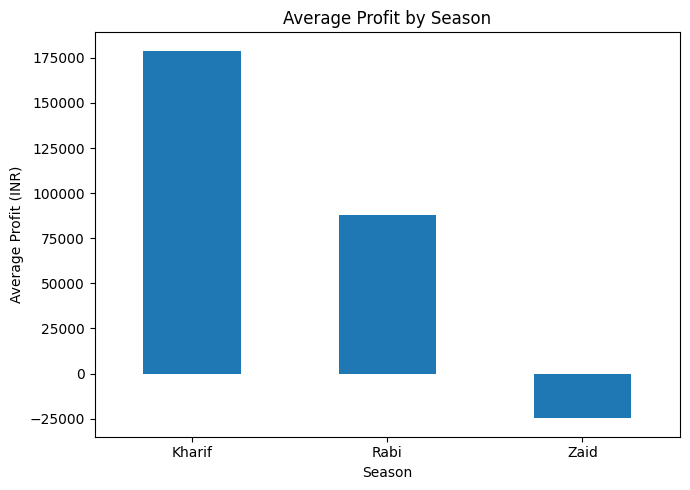

In [22]:
profit_data = df.groupby("Season")["Profit_INR"].mean()

plt.figure(figsize=(7,5))
profit_data.plot(kind="bar")

plt.title("Average Profit by Season")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


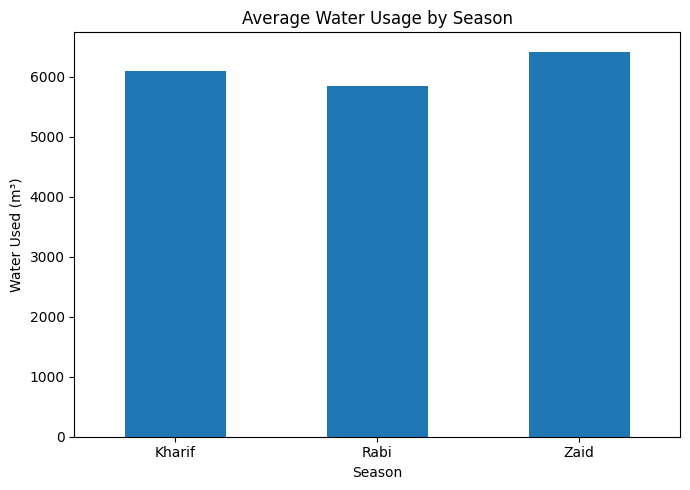

In [24]:
water_data = df.groupby("Season")["Water_Used_m3"].mean()

plt.figure(figsize=(7,5))
water_data.plot(kind="bar")

plt.title("Average Water Usage by Season")
plt.xlabel("Season")
plt.ylabel("Water Used (m³)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


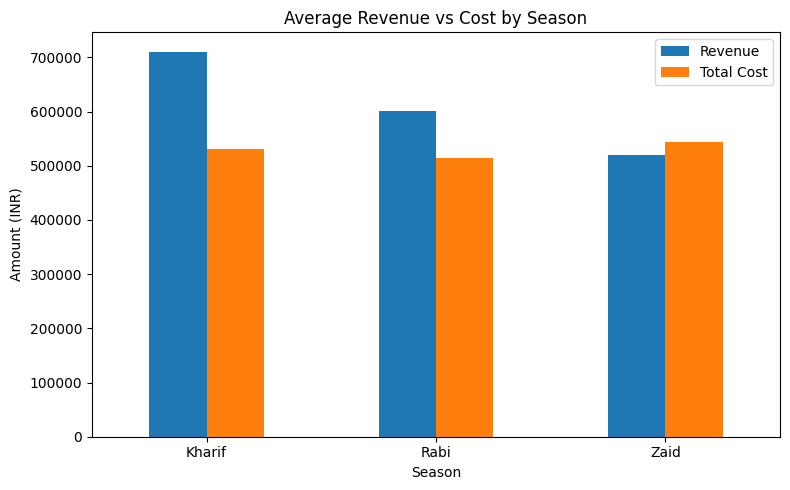

In [25]:
economic_data = df.groupby("Season").agg({
    "Revenue_INR": "mean",
    "Total_Cost_INR": "mean"
})

economic_data.plot(kind="bar", figsize=(8,5))

plt.title("Average Revenue vs Cost by Season")
plt.xlabel("Season")
plt.ylabel("Amount (INR)")
plt.xticks(rotation=0)
plt.legend(["Revenue", "Total Cost"])
plt.tight_layout()
plt.show()

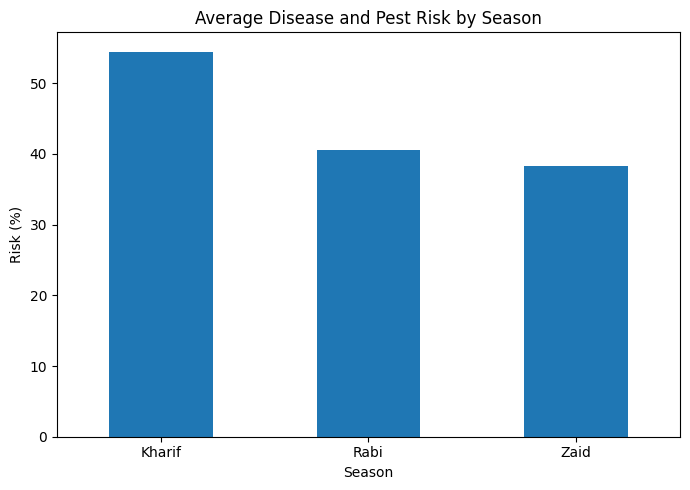

In [26]:
risk_data = df.groupby("Season")["Disease_Pest_Risk_pct"].mean()

plt.figure(figsize=(7,5))
risk_data.plot(kind="bar")

plt.title("Average Disease and Pest Risk by Season")
plt.xlabel("Season")
plt.ylabel("Risk (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


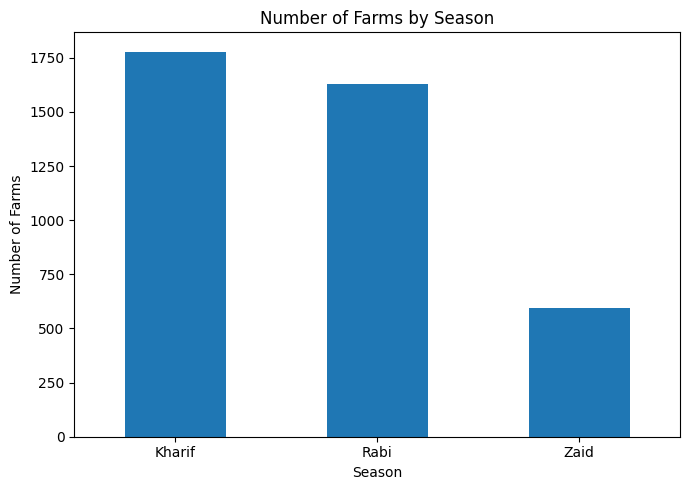

In [27]:

farm_count = df["Season"].value_counts()

plt.figure(figsize=(7,5))
farm_count.plot(kind="bar")

plt.title("Number of Farms by Season")
plt.xlabel("Season")
plt.ylabel("Number of Farms")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [29]:
season_summary = df.groupby("Season").agg(
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Average_Profit=("Profit_INR", "mean"),
    Average_Water=("Water_Used_m3", "mean"),
    Average_Revenue=("Revenue_INR", "mean"),
    Average_Cost=("Total_Cost_INR", "mean"),
    Average_Risk=("Disease_Pest_Risk_pct", "mean")
).round(2)

display(season_summary)


,Average_Yield,Average_Profit,Average_Water,Average_Revenue,Average_Cost,Average_Risk
Season,,,,,,
Kharif,5.64,178914.65,6102.20,710719.06,531804.41,54.47
Rabi,5.08,87689.47,5846.99,601526.05,513836.58,40.48
Zaid,4.67,-24804.82,6419.89,519171.90,543976.73,38.22


In [30]:
best_yield = season_summary["Average_Yield"].idxmax()
best_profit = season_summary["Average_Profit"].idxmax()
highest_water = season_summary["Average_Water"].idxmax()
highest_risk = season_summary["Average_Risk"].idxmax()

print("Best season for crop yield:", best_yield)
print("Best season for profit:", best_profit)
print("Highest water usage:", highest_water)
print("Highest disease/pest risk:", highest_risk)

Best season for crop yield: Kharif
Best season for profit: Kharif
Highest water usage: Zaid
Highest disease/pest risk: Kharif


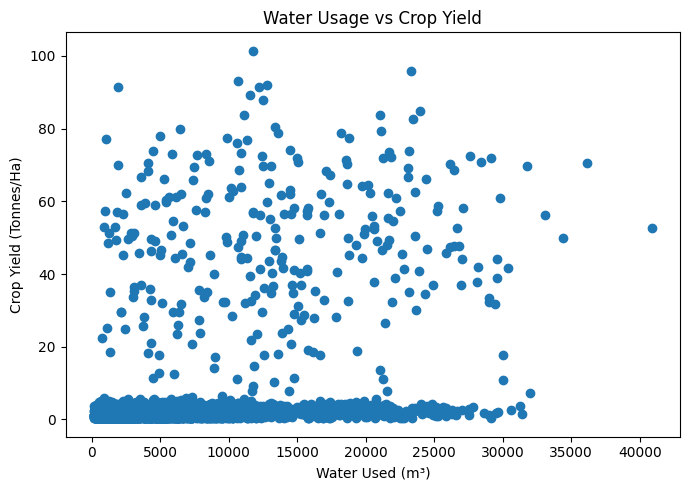

In [31]:
plt.figure(figsize=(7,5))

plt.scatter(
    df["Water_Used_m3"],
    df["Yield_Tonnes_Ha"]
)

plt.title("Water Usage vs Crop Yield")
plt.xlabel("Water Used (m³)")
plt.ylabel("Crop Yield (Tonnes/Ha)")

plt.tight_layout()
plt.show()


In [32]:
print("Highest yield:",
      df["Yield_Tonnes_Ha"].max())

print("Lowest yield:",
      df["Yield_Tonnes_Ha"].min())

print("Highest profit:",
      df["Profit_INR"].max())

print("Lowest profit:",
      df["Profit_INR"].min())


Highest yield: 101.44
Lowest yield: 0.3
Highest profit: 4345421
Lowest profit: -1019223


In [33]:
print("1. Highest average yield season:", best_yield)
print("2. Highest average profit season:", best_profit)
print("3. Highest water usage season:", highest_water)
print("4. Highest disease/pest risk season:", highest_risk)

1. Highest average yield season: Kharif
2. Highest average profit season: Kharif
3. Highest water usage season: Zaid
4. Highest disease/pest risk season: Kharif
